In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# [1] Load Data

In [3]:
df = pd.read_csv("exp_data/span1.csv")
df.head()

,cement,bfs,fa,water,sp,ca,fa.1,age,c_str
0,194.7,0.0,100.5,170.2,7.5,998.0,901.8,3,12.18
1,439.0,177.0,0.0,186.0,11.1,884.9,707.9,3,39.30
2,259.9,100.6,78.4,170.6,10.4,935.7,762.9,28,49.77
3,144.0,170.0,133.0,192.0,8.0,814.0,805.0,28,29.87
4,275.0,0.0,0.0,183.0,0.0,1088.0,808.0,7,14.20


# [2] Explore Data
- This helps in determining data scaling/standardization, imputation, and categorical (if any) variables encoding strategies.
- In this dataset, one only needs to perform data scaling/standardization.

In [4]:
# Dataframe Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cement  515 non-null    float64
 1   bfs     515 non-null    float64
 2   fa      515 non-null    float64
 3   water   515 non-null    float64
 4   sp      515 non-null    float64
 5   ca      515 non-null    float64
 6   fa.1    515 non-null    float64
 7   age     515 non-null    int64  
 8   c_str   515 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 36.3 KB


In [5]:
# Shape & Summary
print("Shape:", df.shape)
df.describe(include="all")

Shape: (515, 9)


,cement,bfs,fa,water,sp,ca,fa.1,age,c_str
count,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,283.358835,75.233010,51.300000,182.775922,5.843301,973.572039,771.991650,44.106796,35.767340
std,108.110460,89.011816,63.028949,20.358217,5.716943,77.940022,78.900296,56.425377,16.388496
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,3.320000
25%,193.500000,0.000000,0.000000,168.000000,0.000000,932.000000,729.650000,14.000000,23.840000
50%,275.100000,20.000000,0.000000,185.700000,6.000000,968.000000,778.500000,28.000000,35.100000
75%,355.450000,145.150000,113.100000,192.900000,9.950000,1029.700000,823.100000,56.000000,45.875000
max,540.000000,359.400000,195.000000,246.900000,32.200000,1134.300000,992.600000,365.000000,80.200000


In [6]:
# Missing Values
print("Missing values:\n", df.isna().sum())

Missing values:
 cement    0
bfs       0
fa        0
water     0
sp        0
ca        0
fa.1      0
age       0
c_str     0
dtype: int64


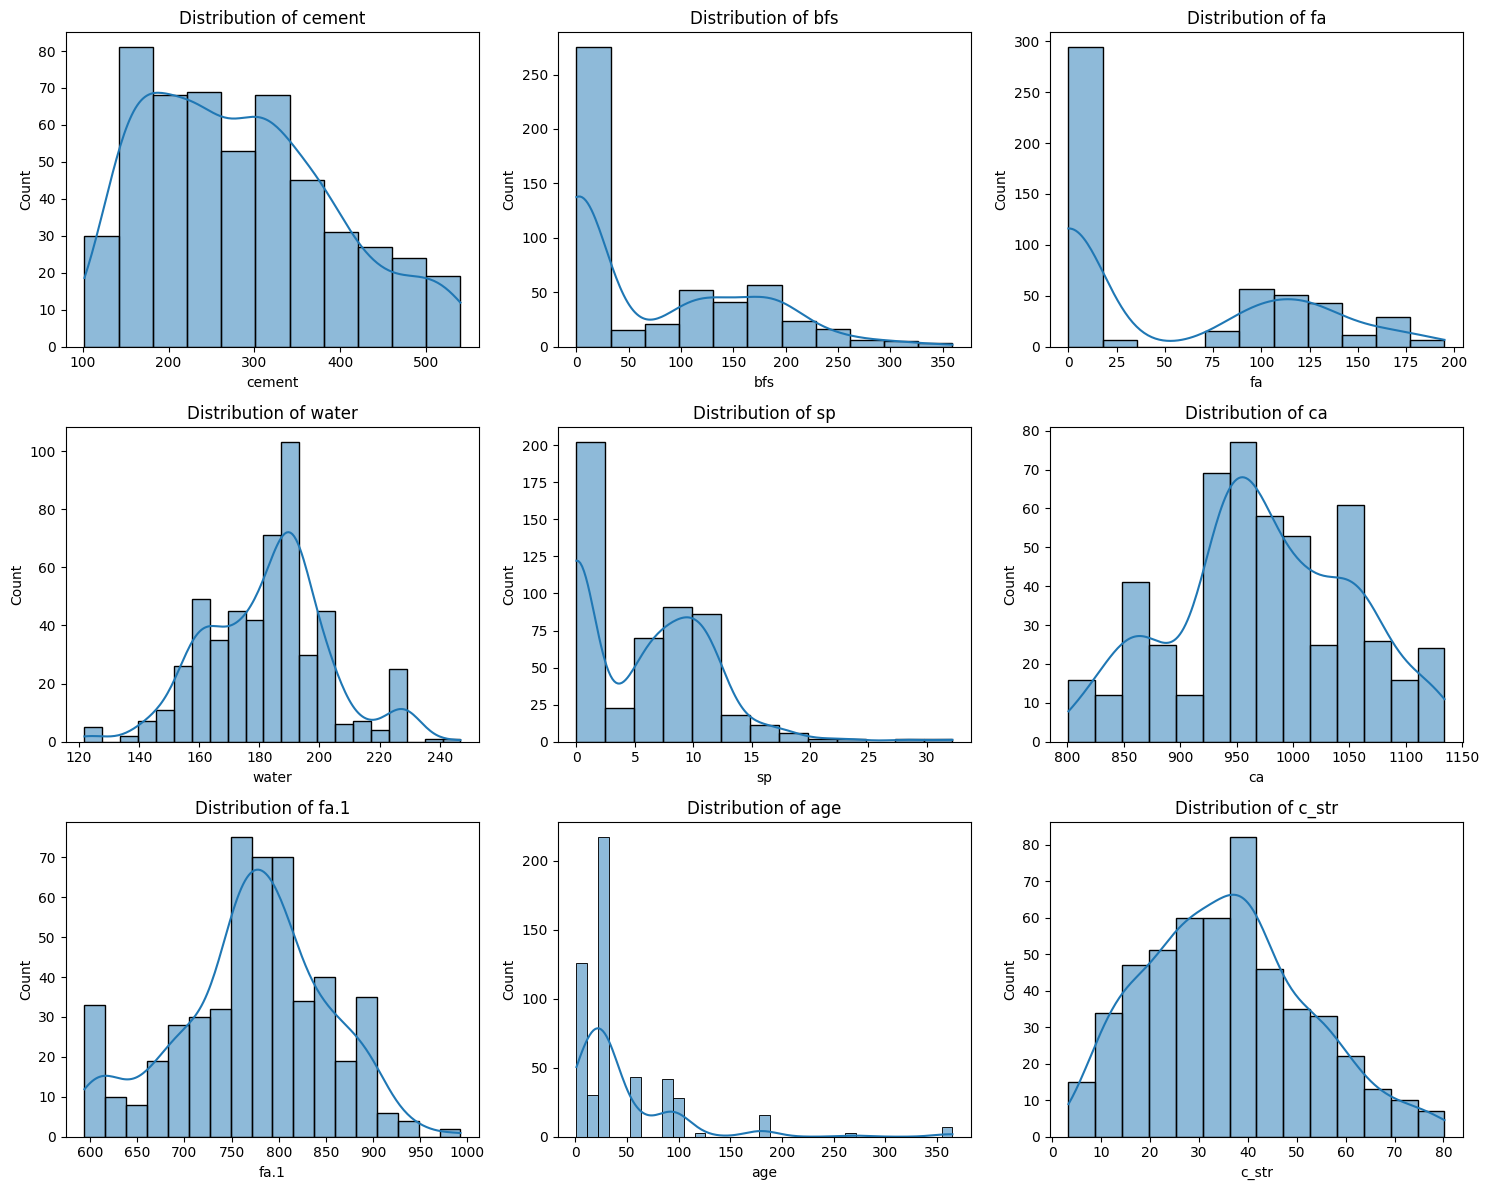

In [8]:
# Plot the Variables
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# [3] Preprocess Data

In [ ]:
df_train = pd.read_csv("exp_data/span-1/train/train.csv")
df_eval = pd.read_csv("exp_data/span-1/eval/eval.csv")
df_test = pd.read_csv("exp_data/span-1/test/test.csv")

In [ ]:
from sklearn.preprocessing import StandardScaler

def preprocess_fit_transform(df_train, df_eval, df_test):
    """
    - Standardize features with mean=0, std=1 (fit on train only)
    """
    target = "c_str"
    X_train = df_train.drop(columns=[target])
    y_train = df_train[target]

    X_eval = df_eval.drop(columns=[target])
    y_eval = df_eval[target]

    X_test = df_test.drop(columns=[target])
    y_test = df_test[target]

    scaler = StandardScaler()

    X_train_s   = scaler.fit_transform(X_train)
    X_eval_s    = scaler.transform(X_eval)
    X_test_s    = scaler.transform(X_test)
    
    return X_train_s, X_eval_s, X_test_s, y_train, y_eval, y_test, scaler

In [ ]:
X_train_s, X_eval_s, X_test_s, y_train, y_eval, y_test, scaler = preprocess_fit_transform(df_train, df_eval, df_test)